# Sri Lankan Currency Note Recognition Using Image Processing and Machine Learning

This notebook reproduces the individual image-processing project. It uses OpenCV for image preprocessing, enhancement, edge and contour detection, feature extraction, and scikit-learn for currency-note denomination recognition.

## 1. Project Setup



In [27]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
DATASET_DIR = PROJECT_DIR / "dataset"
OUTPUT_DIR = PROJECT_DIR / "output_images"
MODEL_DIR = PROJECT_DIR / "model"

print("Dataset exists:", DATASET_DIR.exists())
print("Output folder:", OUTPUT_DIR)

Dataset exists: True
Output folder: c:\Users\User\Documents\IP cousrwork\Currency_Note_Recognition_Project\output_images


## 2. Full process Code



### 2.1 Imports, Folders, and Class Names

In [28]:
# Main libraries
from pathlib import Path

import cv2
import joblib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Project folders
PROJECT_DIR = Path.cwd()
DATASET_DIR = PROJECT_DIR / "dataset"
OUTPUT_DIR = PROJECT_DIR / "output_images"
MODEL_DIR = PROJECT_DIR / "model"

# Currency note classes used in the project
CLASS_NAMES = ["20", "50", "100", "500", "1000", "5000"]
IMAGE_SIZE = (128, 128)

OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

In [29]:
# Output check for Section 2.1
print("Classes:", ", ".join("Rs. " + name for name in CLASS_NAMES))
print("Dataset folder:", DATASET_DIR)
print("Output folder:", OUTPUT_DIR)
print("Model folder:", MODEL_DIR)

Classes: Rs. 20, Rs. 50, Rs. 100, Rs. 500, Rs. 1000, Rs. 5000
Dataset folder: c:\Users\User\Documents\IP cousrwork\Currency_Note_Recognition_Project\dataset
Output folder: c:\Users\User\Documents\IP cousrwork\Currency_Note_Recognition_Project\output_images
Model folder: c:\Users\User\Documents\IP cousrwork\Currency_Note_Recognition_Project\model


### 2.2 Dataset Loading and Image Preprocessing



In [30]:
def image_paths(split):
    # Return image paths and labels from dataset/train, dataset/valid, or dataset/test.
    paths, labels = [], []
    for label in CLASS_NAMES:
        folder = DATASET_DIR / split / label
        for path in sorted(folder.glob("*")):
            if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                paths.append(path)
                labels.append(label)
    return paths, labels


def read_rgb(path):
    # Read an image as RGB and resize it for processing.
    image = cv2.imread(str(path))
    if image is None:
        raise ValueError(f"Could not read image: {path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return cv2.resize(image, IMAGE_SIZE)


def preprocess_steps(path):
    # Create the main image-processing outputs used in the report.
    rgb = read_rgb(path)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Image enhancement: CLAHE improves local contrast.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)

    # Edge and contour detection: finds note boundaries and strong image edges.
    edges = cv2.Canny(enhanced, 80, 180)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_image = rgb.copy()
    cv2.drawContours(contour_image, contours, -1, (255, 0, 0), 2)
    return rgb, gray, enhanced, edges, contour_image

In [31]:
# Output check for Section 2.2
for split in ["train", "valid", "test"]:
    paths, labels = image_paths(split)
    print(f"{split.title()} images: {len(paths)}")

sample_paths, _ = image_paths("train")
sample_image = sample_paths[0]
processed = preprocess_steps(sample_image)
print("Sample image:", sample_image.name)
print("Preprocessing outputs:", [image.shape for image in processed])

Train images: 213
Valid images: 18
Test images: 14
Sample image: cyber_WhatsApp-Image-2026-02-14-at-1-00-02-PM_jpeg.rf.58d2594b5a5d834d9c16594ebf4979b7.jpg
Preprocessing outputs: [(128, 128, 3), (128, 128), (128, 128), (128, 128), (128, 128, 3)]


### 2.3 Feature Extraction



In [32]:
def extract_features(path):
    # Extract color, texture, and edge features from one note image.
    rgb, gray, enhanced, edges, _ = preprocess_steps(path)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)

    features = []
    grid_size = 2
    hist_bins = 48

    # Color features: regional histograms keep color layout information.
    for image in (rgb, hsv, lab):
        height, width = image.shape[:2]
        for grid_y in range(grid_size):
            for grid_x in range(grid_size):
                patch = image[
                    grid_y * height // grid_size : (grid_y + 1) * height // grid_size,
                    grid_x * width // grid_size : (grid_x + 1) * width // grid_size,
                ]
                for channel in cv2.split(patch):
                    hist = cv2.calcHist([channel], [0], None, [hist_bins], [0, 256]).flatten()
                    features.extend(hist / max(hist.sum(), 1))

    # Edge and texture features.
    features.append(float(np.mean(edges > 0)))
    features.append(float(np.std(gray)))
    features.append(float(np.mean(gray)))
    return np.array(features, dtype=np.float32)


def make_dataset(split):
    # Build feature matrix X and label array y for a dataset split.
    paths, labels = image_paths(split)
    x = np.vstack([extract_features(path) for path in paths])
    y = np.array(labels)
    return paths, x, y

In [33]:
# Output check for Section 2.3
sample_features = extract_features(sample_image)
print("Feature vector size:", sample_features.shape[0])
print("First 10 feature values:", np.round(sample_features[:10], 4))

Feature vector size: 1731
First 10 feature values: [0.000e+00 0.000e+00 0.000e+00 8.010e-02 4.805e-01 1.843e-01 5.100e-03
 1.500e-03 2.000e-04 1.000e-03]


### 2.4 Save Output Images



In [34]:
def save_dataset_samples():
    # Save one sample image for each currency denomination.
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    train_paths, _ = image_paths("train")
    for ax, label in zip(axes.ravel(), CLASS_NAMES):
        selected = next(path for path in train_paths if path.parent.name == label)
        ax.imshow(read_rgb(selected))
        ax.set_title(f"Rs. {label}")
        ax.axis("off")
    fig.suptitle("Dataset Samples")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "dataset_samples.png", dpi=150)
    plt.close(fig)


def save_preprocessing_figure(sample_path):
    # Save original, enhanced, edge, and contour comparison.
    images = preprocess_steps(sample_path)
    titles = ["Original", "Grayscale", "CLAHE Enhanced", "Canny Edges", "Contours"]
    fig, axes = plt.subplots(1, 5, figsize=(14, 3.2))
    for ax, image, title in zip(axes, images, titles):
        if image.ndim == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(image)
        ax.set_title(title)
        ax.axis("off")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "preprocessing_steps.png", dpi=150)
    plt.close(fig)


def save_accuracy_graph(scores):
    # Save training, validation, and testing accuracy as a bar chart.
    fig, ax = plt.subplots(figsize=(6.5, 4))
    names = list(scores.keys())
    values = [scores[name] * 100 for name in names]
    bars = ax.bar(names, values, color=["#24486E", "#4D7EA8", "#8DB3D3"])
    ax.set_ylim(0, 100)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Recognition Accuracy")
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 1, f"{value:.1f}%", ha="center")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "accuracy_graph.png", dpi=150)
    plt.close(fig)


def save_confusion_matrix(y_true, y_pred):
    # Save confusion matrix to show correct and incorrect predictions.
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels([f"Rs. {c}" for c in CLASS_NAMES], rotation=45, ha="right")
    ax.set_yticklabels([f"Rs. {c}" for c in CLASS_NAMES])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Confusion Matrix")
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            ax.text(col, row, str(cm[row, col]), ha="center", va="center", color="#111827")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
    plt.close(fig)


def save_prediction_result(model, test_paths, y_true):
    # Save one example prediction image.
    sample_path = test_paths[0]
    prediction = model.predict([extract_features(sample_path)])[0]
    confidence = max(model.predict_proba([extract_features(sample_path)])[0]) * 100
    fig, ax = plt.subplots(figsize=(5.8, 4))
    ax.imshow(read_rgb(sample_path))
    ax.axis("off")
    ax.set_title(
        f"Actual: Rs. {y_true[0]} | Predicted: Rs. {prediction} | Confidence: {confidence:.1f}%"
    )
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "prediction_result.png", dpi=150)
    plt.close(fig)

Saved sample and preprocessing images:
dataset_samples.png exists: True


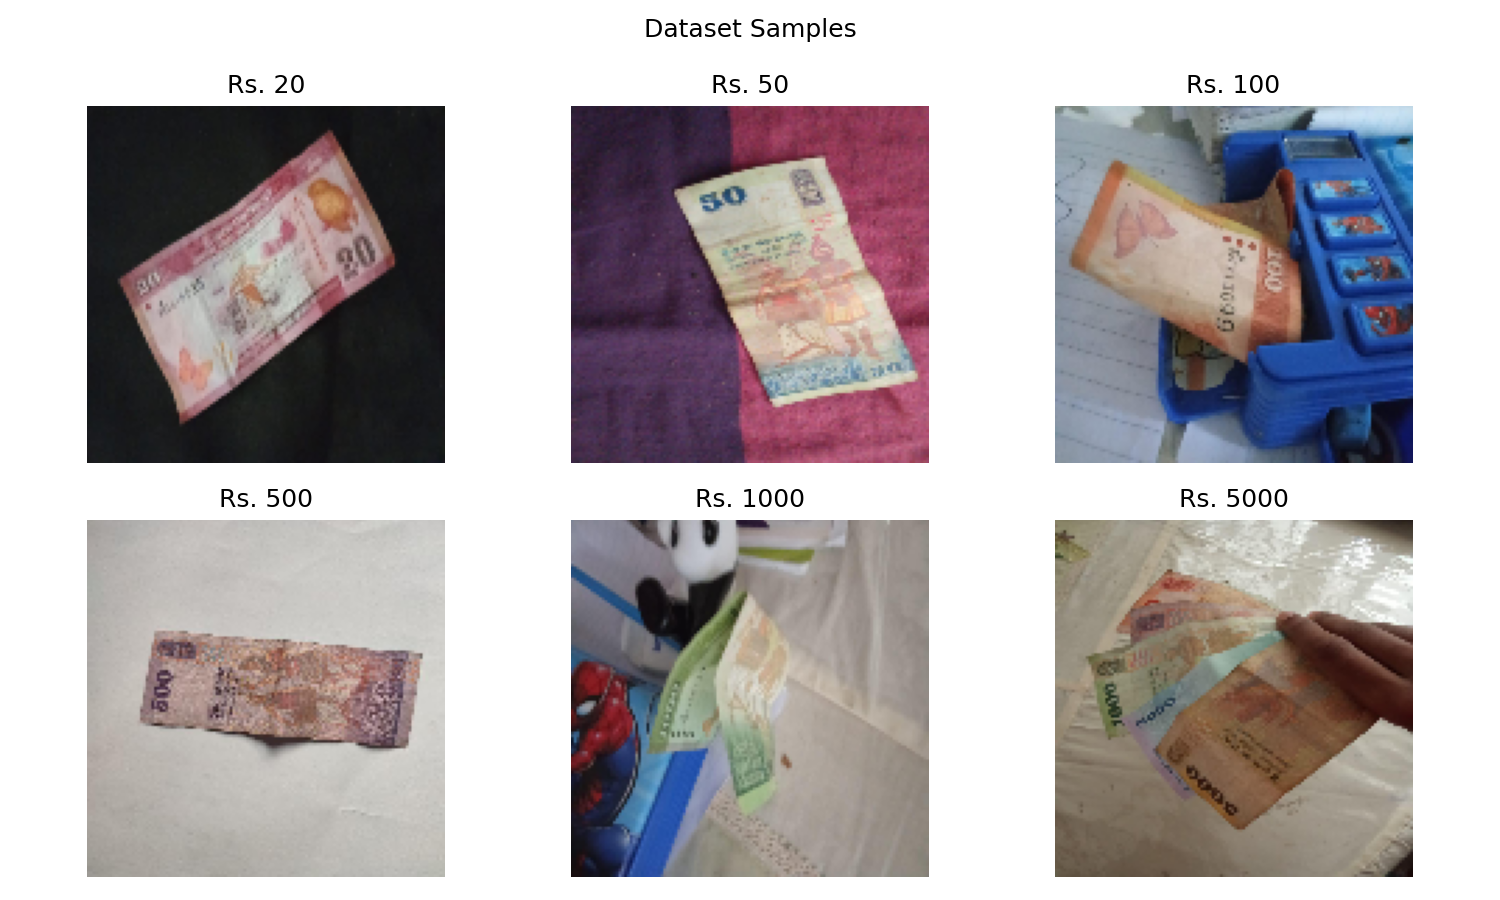

preprocessing_steps.png exists: True


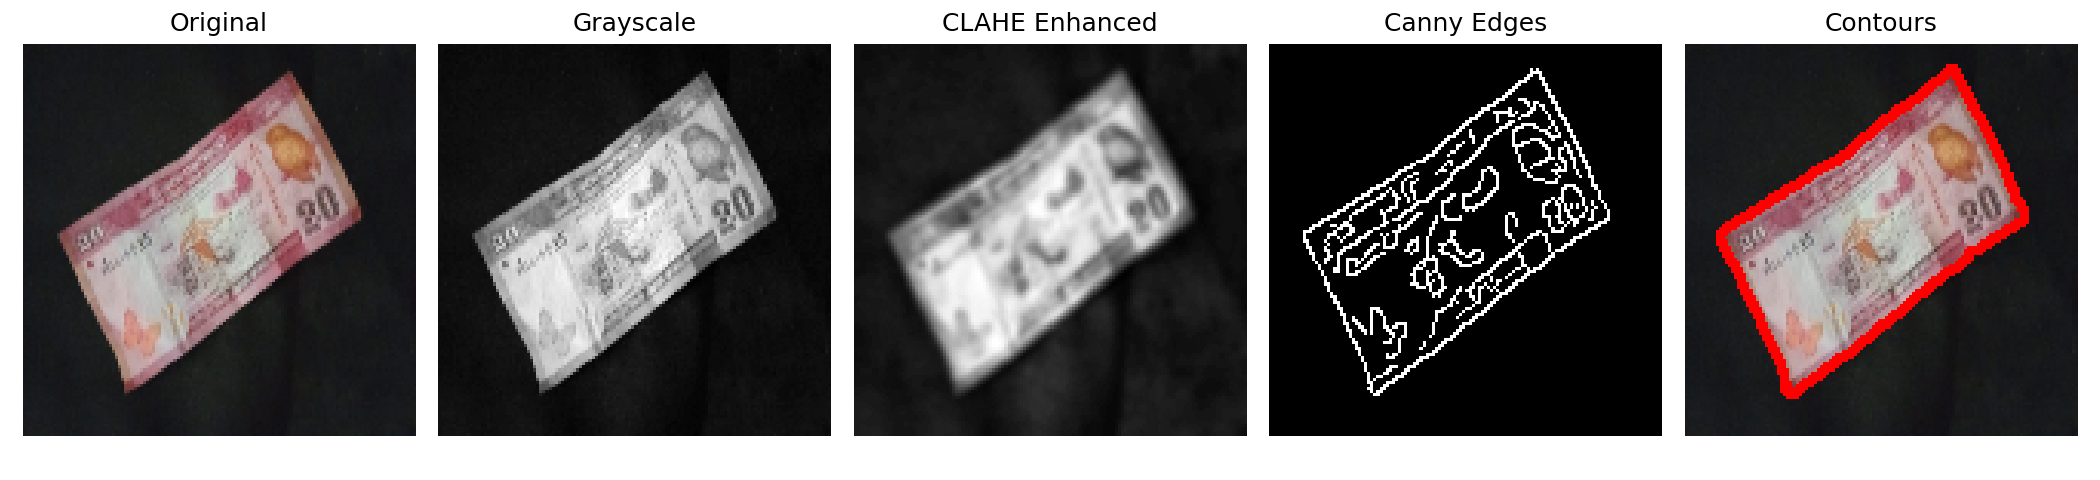

In [35]:
# Output check for Section 2.4
save_dataset_samples()
save_preprocessing_figure(sample_image)

print("Saved sample and preprocessing images:")
for filename in ["dataset_samples.png", "preprocessing_steps.png"]:
    path = OUTPUT_DIR / filename
    print(filename, "exists:", path.exists())
    display(Image(filename=str(path)))

### 2.5 Train, Evaluate, and Save Results



In [36]:
def main():
    # Run the complete currency note recognition workflow.
    save_dataset_samples()
    sample_paths, _ = image_paths("train")
    save_preprocessing_figure(sample_paths[0])

    train_paths, x_train, y_train = make_dataset("train")
    valid_paths, x_valid, y_valid = make_dataset("valid")
    test_paths, x_test, y_test = make_dataset("test")

    # Random Forest is used because it performs well on color/texture feature vectors.
    model = RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    )
    model.fit(x_train, y_train)

    train_pred = model.predict(x_train)
    valid_pred = model.predict(x_valid)
    test_pred = model.predict(x_test)
    scores = {
        "Training": accuracy_score(y_train, train_pred),
        "Validation": accuracy_score(y_valid, valid_pred),
        "Testing": accuracy_score(y_test, test_pred),
    }

    save_accuracy_graph(scores)
    save_confusion_matrix(y_test, test_pred)
    save_prediction_result(model, test_paths, y_test)

    report = classification_report(y_test, test_pred, labels=CLASS_NAMES, zero_division=0)
    (OUTPUT_DIR / "classification_report.txt").write_text(report, encoding="utf-8")
    (OUTPUT_DIR / "accuracy_summary.txt").write_text(
        "\n".join(f"{name} Accuracy: {score * 100:.2f}%" for name, score in scores.items()),
        encoding="utf-8",
    )
    joblib.dump(model, MODEL_DIR / "currency_note_classifier.joblib")

    print("Dataset sizes:")
    print(f"Training: {len(train_paths)} images")
    print(f"Validation: {len(valid_paths)} images")
    print(f"Testing: {len(test_paths)} images")
    print("\nAccuracy:")
    for name, score in scores.items():
        print(f"{name}: {score * 100:.2f}%")
    print("\nClassification report:")
    print(report)

## 3. Run the Project

Run this cell after Section 2. It generates all required outputs.

Dataset sizes:
Training: 213 images
Validation: 18 images
Testing: 14 images

Accuracy:
Training: 100.00%
Validation: 83.33%
Testing: 92.86%

Classification report:
              precision    recall  f1-score   support

          20       1.00      1.00      1.00         4
          50       1.00      0.50      0.67         2
         100       0.75      1.00      0.86         3
         500       1.00      1.00      1.00         1
        1000       1.00      1.00      1.00         3
        5000       1.00      1.00      1.00         1

    accuracy                           0.93        14
   macro avg       0.96      0.92      0.92        14
weighted avg       0.95      0.93      0.92        14


Generated final output images:
accuracy_graph.png exists: True


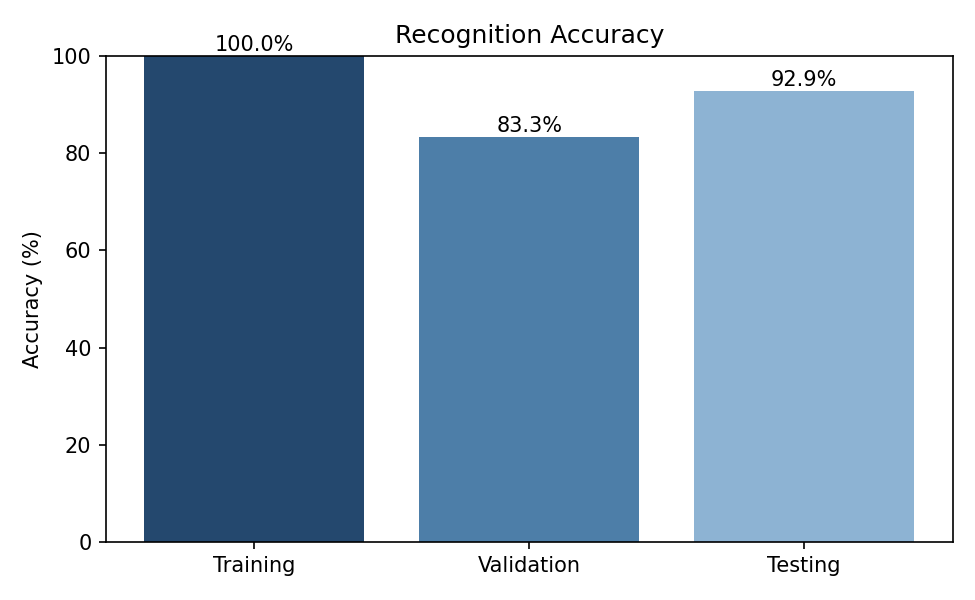

confusion_matrix.png exists: True


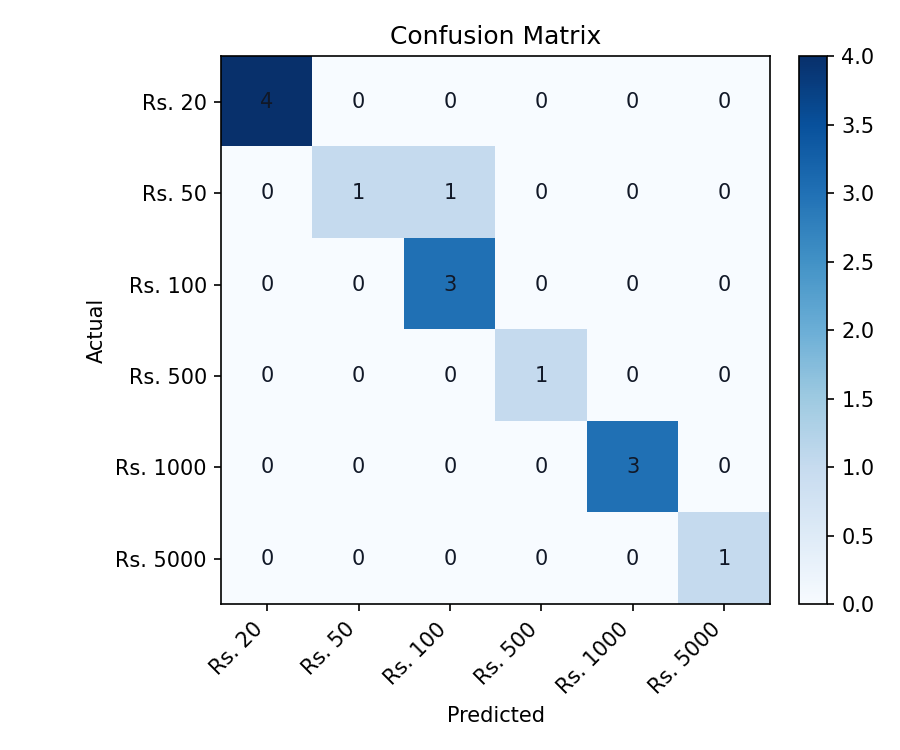

prediction_result.png exists: True


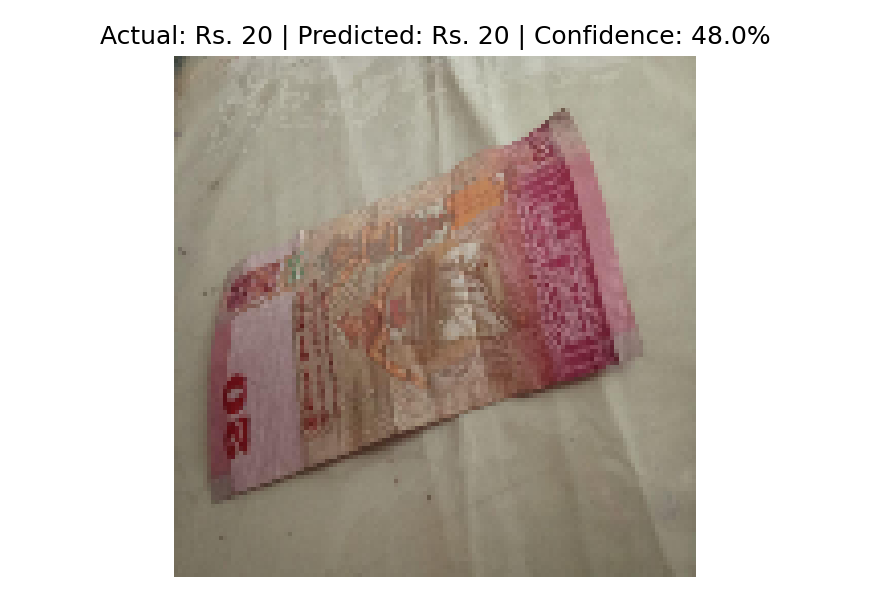

In [37]:
main()

print("\nGenerated final output images:")
for filename in ["accuracy_graph.png", "confusion_matrix.png", "prediction_result.png"]:
    path = OUTPUT_DIR / filename
    print(filename, "exists:", path.exists())
    display(Image(filename=str(path)))

## 4. Generated Outputs


- `output_images/dataset_samples.png`
- `output_images/preprocessing_steps.png`
- `output_images/accuracy_graph.png`
- `output_images/confusion_matrix.png`
- `output_images/prediction_result.png`
- `output_images/accuracy_summary.txt`
- `output_images/classification_report.txt`
- `model/currency_note_classifier.joblib`